In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
import xgboost as xgb

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline


In [37]:
df = pd.read_csv("../data/city_day.csv")
df.head()


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [39]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [40]:
df.columns

Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6236 entries, 2123 to 29529
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        6236 non-null   object 
 1   Date        6236 non-null   object 
 2   PM2.5       6236 non-null   float64
 3   PM10        6236 non-null   float64
 4   NO          6236 non-null   float64
 5   NO2         6236 non-null   float64
 6   NOx         6236 non-null   float64
 7   NH3         6236 non-null   float64
 8   CO          6236 non-null   float64
 9   SO2         6236 non-null   float64
 10  O3          6236 non-null   float64
 11  Benzene     6236 non-null   float64
 12  Toluene     6236 non-null   float64
 13  Xylene      6236 non-null   float64
 14  AQI         6236 non-null   float64
 15  AQI_Bucket  6236 non-null   object 
dtypes: float64(13), object(3)
memory usage: 828.2+ KB


#####
--->
we will keep the numerical features in our dataframe so that we can apply normalization and make it prepared for applying the ML techniques . So we would be dropping the city , date and aqi_bucket from our df's features but before that we would like to see the number of null values in our dataset


In [41]:
df.isna().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

##### ---> We see that there are many null values inside the dataframe , also we can't handle the null values inside the target values


In [42]:
# Drop NA or fill
df = df.dropna()

# Example: Assume target = 'AQI', and features include some numeric columns
features = df.drop(columns=['AQI','City', 'Date','AQI_Bucket'])
target = df['AQI']




In [43]:
df.isna().sum()

City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
dtype: int64

##### ---> null values removed!

Text(0.5, 1.0, 'Average AQI by City')

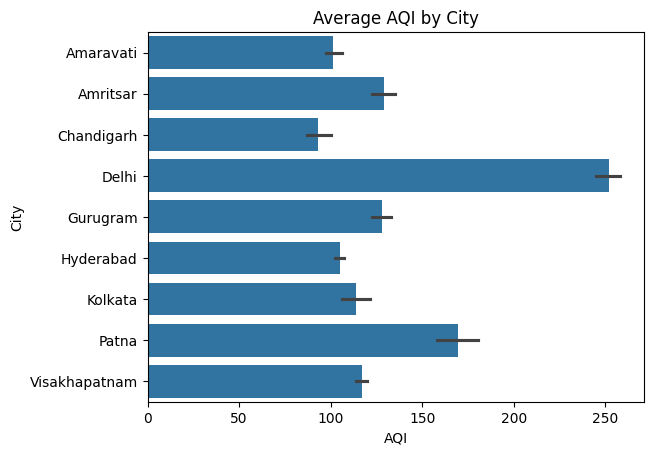

In [50]:
sns.barplot(x='AQI', y='City', data=df, estimator=np.mean)
plt.title("Average AQI by City")

##### 
--->
From this it is inferrable that the average AQI is higher in the city of DELHI, followed by PATNA and AMRITSAR. The average AQI in CHANDIGARH is the lowest among the  cities. This suggests that Delhi has the worst air quality on average, while CHANDIGARH has the best air quality on average. However, it is important to note that this is just an average and does not account for variations in AQI over time or other factors that may influence air quality.

In [44]:
# Optional: scale numeric features

scaler = StandardScaler()
X = scaler.fit_transform(features)
y = target.values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##### 
---> So we applied standard scaler to normalize the numerical  features and also divided the data into test and train .

In [45]:
models = {
    'ElasticNet': ElasticNet(),
    'SVM': SVR(),
    'KNN': KNeighborsRegressor(),
    'Random Forest': RandomForestRegressor(),
    'XGBoost': xgb.XGBRegressor()
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, scoring='r2', cv=kf)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results[name] = {
        'R2': r2_score(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'MAE': mean_absolute_error(y_test, preds),
        'CV R2 Mean': np.mean(scores)
    }

pd.DataFrame(results).T.sort_values('R2', ascending=False)


,R2,RMSE,MAE,CV R2 Mean
Random Forest,0.948739,20.652005,13.888494,0.937568
XGBoost,0.941306,22.098605,14.615331,0.930897
KNN,0.928508,24.389101,16.459776,0.919219
ElasticNet,0.877085,31.979379,23.249954,0.872098
SVM,0.731411,47.272771,26.409372,0.684967


['ElasticNet', 'SVM', 'KNN', 'Random Forest', 'XGBoost']


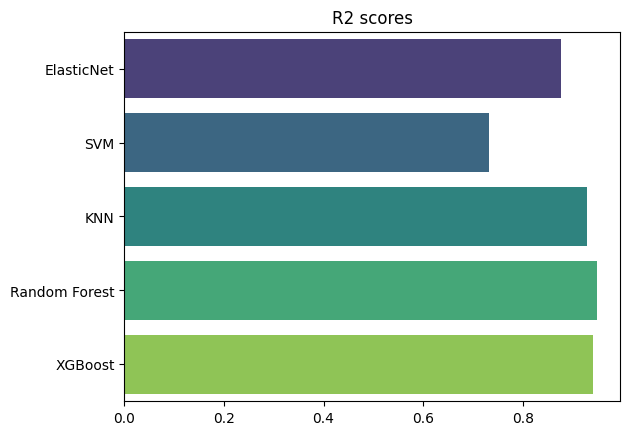

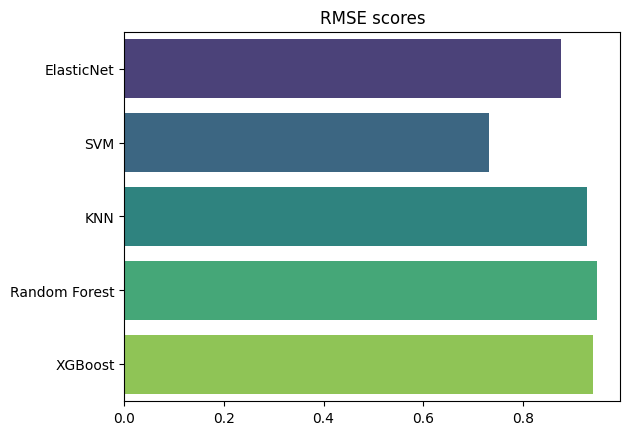

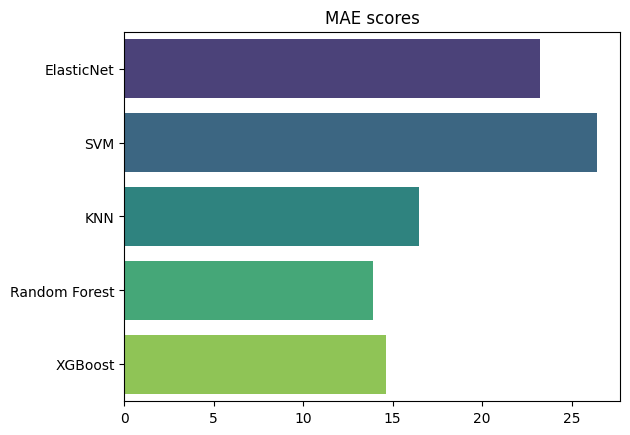

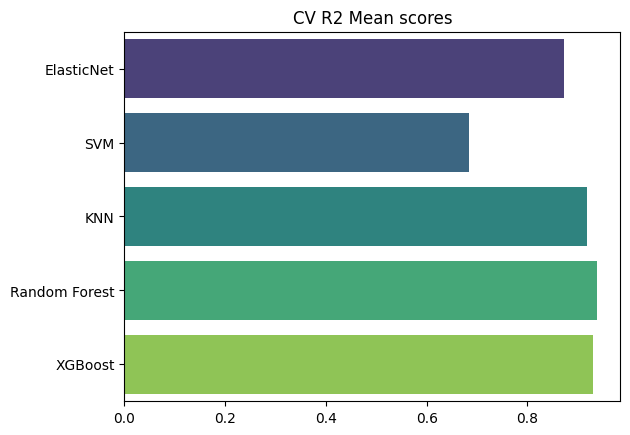

In [76]:
models = list(results.keys())
print(models)
# R2 scores
r2_scores = [results[model]['R2'] for model in models]
sns.barplot(x=r2_scores, y=models, palette='viridis')
plt.title("R2 scores")
plt.show()

# RMSE scores
rmse_scores = [results[model]['RMSE'] for model in models]
sns.barplot(x=r2_scores, y=models, palette='viridis')
plt.title("RMSE scores")
plt.show()


# MAE scores
mae_scores = [results[model]['MAE'] for model in models]
sns.barplot(x=mae_scores, y=models, palette='viridis')
plt.title("MAE scores")
plt.show()


# CV R2 Mean scores
cv_r2_mean = [results[model]['CV R2 Mean'] for model in models]
sns.barplot(x=cv_r2_mean, y=models, palette='viridis')
plt.title("CV R2 Mean scores")
plt.show()


